In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("train_scaled.csv")
X_val = pd.read_csv("val_scaled.csv")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

X_train.head()

Train shape: (16561, 18)
Validation shape: (4070, 18)


,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,-1.556308,-0.818512,2.043793,0.0,-1.581191,-1.092662,-1.963014,1.318090,-1.221017,-0.471297,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436
1,-1.541948,1.966124,-1.031739,0.0,-1.721722,-0.565155,-1.756664,1.591518,-1.645675,-0.621789,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895
2,-1.527588,0.824880,1.018616,0.0,-2.263772,-0.356453,-1.106382,2.013053,-0.796358,-0.492481,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524
3,-1.513228,1.600926,-1.373465,0.0,-2.002785,-1.041719,-1.427619,0.999091,-1.645675,-0.326102,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974
4,-1.498868,0.231433,1.360341,0.0,-1.902406,-1.883102,-0.709298,1.990267,-0.937911,-0.319923,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627


In [2]:
y_train = pd.read_csv("y_train_scaled.csv")
y_val = pd.read_csv("y_val.csv")

In [3]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 18)
y_train: (16561, 1)
X_val: (4070, 18)
y_val: (4070, 1)


## Linear Regression Model

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

In [5]:
mae_lr = mean_absolute_error(y_val, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_val, y_pred_lr)
)

r2_lr = r2_score(y_val, y_pred_lr)

print("Linear Regression")
print("------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
------------------
MAE : 25.17367014792761
RMSE: 31.675902225783492
R²  : 0.7672105397060078


## Random Forrest Model

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

d:\Anaconda\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [7]:
mae_rf = mean_absolute_error(y_val, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_val, y_pred_rf)
)

r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest")
print("------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
------------------
MAE : 23.95581203931204
RMSE: 31.622934056205093
R²  : 0.7679884258164387


## XGBoost Model

In [5]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)


In [8]:
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_val, y_pred_xgb)
)

r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost")
print("------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
------------------
MAE : 23.5859432220459
RMSE: 31.260621241902527
R²  : 0.7732744216918945


In [16]:
joblib.dump(lr_model, "linear_regression_rul.pkl")
joblib.dump(rf_model, "random_forest_rul.pkl")
joblib.dump(xgb_model, "xgboost_rul.pkl")

['xgboost_rul.pkl']

In [17]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
2,XGBoost,23.585943,31.260621,0.773274
1,Random Forest,23.955812,31.622934,0.767988
0,Linear Regression,25.173670,31.675902,0.767211


### Analysis of the XGB Model

In [ ]:
results_xgb = pd.DataFrame({
    "Actual_RUL": np.asarray(y_val).ravel(),
    "Predicted_RUL": np.asarray(y_pred_xgb).ravel()
})

results_xgb["Residual"] = (
    results_xgb["Actual_RUL"] -
    results_xgb["Predicted_RUL"]
)

results_xgb["Absolute_Error"] = (
    results_xgb["Residual"].abs()
)

results_xgb.head(50)

,Actual_RUL,Predicted_RUL,Residual,Absolute_Error
0,191,230.141907,-39.141907,39.141907
1,190,206.674744,-16.674744,16.674744
2,189,213.292877,-24.292877,24.292877
3,188,222.859131,-34.859131,34.859131
4,187,216.853394,-29.853394,29.853394


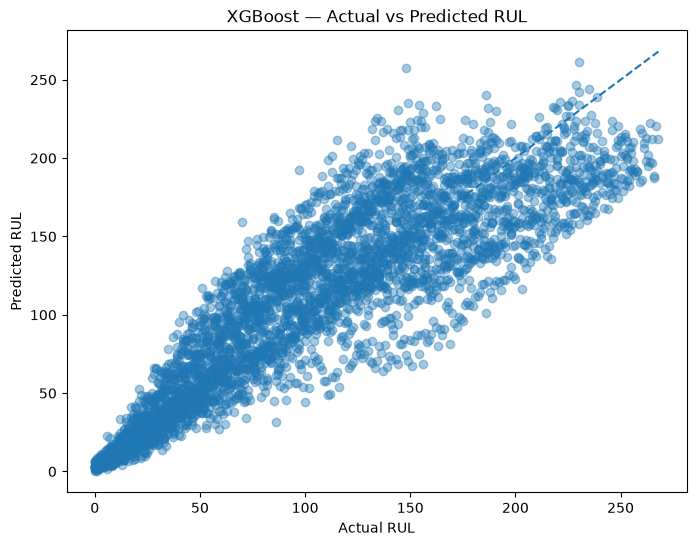

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    results_xgb["Actual_RUL"],
    results_xgb["Predicted_RUL"],
    alpha=0.4
)

# Perfect prediction line
min_rul = min(
    results_xgb["Actual_RUL"].min(),
    results_xgb["Predicted_RUL"].min()
)

max_rul = max(
    results_xgb["Actual_RUL"].max(),
    results_xgb["Predicted_RUL"].max()
)

plt.plot(
    [min_rul, max_rul],
    [min_rul, max_rul],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost — Actual vs Predicted RUL")

plt.show()

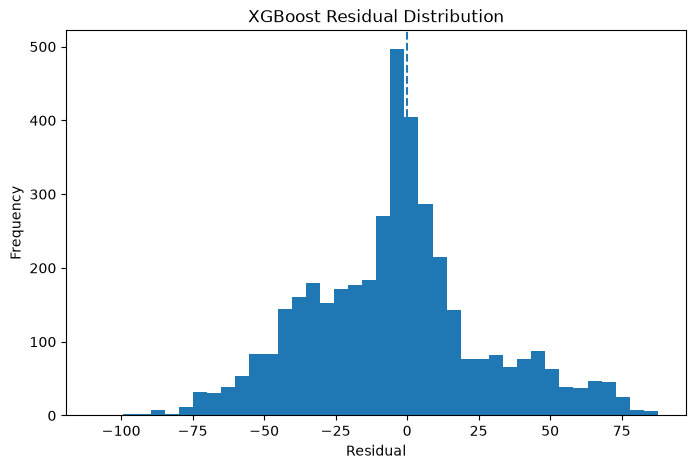

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    results_xgb["Residual"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("XGBoost Residual Distribution")

plt.show()

In [21]:
results_xgb["RUL_Group"] = pd.cut(
    results_xgb["Actual_RUL"],
    bins=[-1, 20, 50, 100, np.inf],
    labels=[
        "0-20",
        "21-50",
        "51-100",
        "100+"
    ]
)

In [22]:
group_performance = (
    results_xgb
    .groupby("RUL_Group", observed=True)
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2))),
        Count=("Actual_RUL", "size")
    )
    .reset_index()
)

group_performance

,RUL_Group,MAE,RMSE,Count
0,0-20,4.395432,5.934121,420
1,21-50,12.308159,17.006120,600
2,51-100,25.144095,31.299046,1000
3,100+,30.058399,37.019221,2050


In [23]:
overestimation = (
    results_xgb["Residual"] < 0
).mean() * 100

underestimation = (
    results_xgb["Residual"] > 0
).mean() * 100

print(f"RUL overestimation: {overestimation:.2f}%")
print(f"RUL underestimation: {underestimation:.2f}%")

RUL overestimation: 58.45%
RUL underestimation: 41.55%


In [24]:
critical_region = results_xgb[
    results_xgb["Actual_RUL"] <= 20
]

dangerous_overestimation = critical_region[
    critical_region["Residual"] < 0
]

print("Critical region samples:",
      len(critical_region))

print("Overestimated critical samples:",
      len(dangerous_overestimation))

print(
    "Percentage:",
    len(dangerous_overestimation)
    / len(critical_region) * 100
)

print(
    "Average overestimation:",
    -dangerous_overestimation["Residual"].mean()
)

print(
    "Maximum overestimation:",
    -dangerous_overestimation["Residual"].min()
)

Critical region samples: 420
Overestimated critical samples: 299
Percentage: 71.19047619047619
Average overestimation: 4.992400498493858
Maximum overestimation: 24.36806869506836


In [31]:
critical_errors = (
    results_xgb[
        results_xgb["Actual_RUL"] <= 20
    ]
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)

critical_errors.head(10)

,Actual_RUL,Predicted_RUL,Residual,Absolute_Error,RUL_Group
3025,17,41.368069,-24.368069,24.368069,0-20
3023,19,41.820538,-22.820538,22.820538,0-20
2392,19,40.828033,-21.828033,21.828033,0-20
179,12,33.342335,-21.342335,21.342335,0-20
3176,20,40.482994,-20.482994,20.482994,0-20
2140,15,34.294292,-19.294292,19.294292,0-20
3024,18,36.691231,-18.691231,18.691231,0-20
3410,17,34.897480,-17.897480,17.897480,0-20
171,20,36.812874,-16.812874,16.812874,0-20
3661,6,22.498535,-16.498535,16.498535,0-20


In [28]:
severe_overestimation = critical_region[
    critical_region["Residual"] < -10
]

print(
    "Severe overestimations:",
    len(severe_overestimation)
)

print(
    "Percentage:",
    len(severe_overestimation)
    / len(critical_region) * 100
)

Severe overestimations: 30
Percentage: 7.142857142857142


In [29]:
very_severe_overestimation = critical_region[
    critical_region["Residual"] < -20
]

print(
    "20+ cycle overestimations:",
    len(very_severe_overestimation)
)

print(
    "Percentage:",
    len(very_severe_overestimation)
    / len(critical_region) * 100
)

20+ cycle overestimations: 5
Percentage: 1.1904761904761905


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,cycle,0.416649
1,sensor_11,0.179114
2,sensor_4,0.078690
3,sensor_12,0.041321
4,sensor_14,0.039191
5,sensor_9,0.028541
6,sensor_7,0.026339
7,sensor_8,0.025057
8,sensor_15,0.024959
9,sensor_21,0.021245


In [9]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    xgb_model,
    X_val,
    y_val,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [10]:
perm_results = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_STD": perm_importance.importances_std
})

perm_results = (
    perm_results
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

perm_results.head(15)

,Feature,Importance_Mean,Importance_STD
0,cycle,21.673386,0.419773
1,sensor_11,4.181631,0.098281
2,sensor_4,1.617170,0.089227
3,sensor_12,1.583656,0.042608
4,sensor_14,1.473612,0.120100
5,sensor_9,0.929631,0.093808
6,sensor_15,0.892165,0.024394
7,sensor_21,0.742036,0.086602
8,sensor_2,0.716184,0.041381
9,sensor_3,0.537899,0.056980


In [11]:
X_train_no_cycle = X_train.drop(columns=["cycle"])
X_val_no_cycle = X_val.drop(columns=["cycle"])

print("Original features:", X_train.shape[1])
print("Without cycle:", X_train_no_cycle.shape[1])

Original features: 18
Without cycle: 17


In [12]:
xgb_no_cycle = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_no_cycle.fit(
    X_train_no_cycle,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
y_pred_no_cycle = xgb_no_cycle.predict(
    X_val_no_cycle
)

In [14]:
mae_no_cycle = mean_absolute_error(
    y_val,
    y_pred_no_cycle
)

rmse_no_cycle = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_no_cycle
    )
)

r2_no_cycle = r2_score(
    y_val,
    y_pred_no_cycle
)

print("XGBoost WITHOUT cycle")
print("----------------------")
print("MAE :", mae_no_cycle)
print("RMSE:", rmse_no_cycle)
print("R²  :", r2_no_cycle)

XGBoost WITHOUT cycle
----------------------
MAE : 25.832033157348633
RMSE: 35.50150951346119
R²  : 0.7075854539871216


In [15]:
comparison = pd.DataFrame({
    "Model": [
        "XGBoost + cycle",
        "XGBoost without cycle"
    ],
    "MAE": [
        mae_xgb,
        mae_no_cycle
    ],
    "RMSE": [
        rmse_xgb,
        rmse_no_cycle
    ],
    "R2": [
        r2_xgb,
        r2_no_cycle
    ]
})

comparison

,Model,MAE,RMSE,R2
0,XGBoost + cycle,23.585943,31.260621,0.773274
1,XGBoost without cycle,25.832033,35.501510,0.707585


### Hyperparameter Tuning

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2, 5]
}

In [17]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a fu

In [18]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best parameters:
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

Best CV MAE:
27.88102149963379


In [19]:
best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_val)

mae_tuned = mean_absolute_error(y_val, y_pred_tuned)

rmse_tuned = np.sqrt(
    mean_squared_error(y_val, y_pred_tuned)
)

r2_tuned = r2_score(y_val, y_pred_tuned)

print("Tuned XGBoost")
print("----------------")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned XGBoost
----------------
MAE : 22.53611946105957
RMSE: 29.369695955650336
R²  : 0.7998737096786499


In [20]:
tuning_results = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        mae_xgb,
        mae_tuned
    ],
    "RMSE": [
        rmse_xgb,
        rmse_tuned
    ],
    "R2": [
        r2_xgb,
        r2_tuned
    ]
})

tuning_results

,Model,MAE,RMSE,R2
0,Baseline XGBoost,23.585943,31.260621,0.773274
1,Tuned XGBoost,22.536119,29.369696,0.799874
